In [1]:
import cospar as cs
import pandas as pd
import scipy
import numpy as np
import os
import scanpy as sc
from cospar.plotting import _utils as pl_util

%reload_ext autoreload
%autoreload 2

import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
cs.settings.set_figure_params(format="png", figsize=[4, 3.5], dpi=100, fontsize=12, pointsize=3)

### CoSpar Basics

In [5]:
adata = sc.read_h5ad('../../datasets/CordBlood_Refine/adata_update.h5ad')
adata

AnnData object with n_obs × n_vars = 24885 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

In [6]:
adata.obs['meta_clones'] = adata.obs['Meta clones'].values
adata.obs['label_man'] = adata.obs['def_lab'].values
adata = adata[adata.obs['meta_clones'] != '-1.0', :]
adata.obs['Clone_ID'] = [name[6:] for name in adata.obs.clones.values]

/tmp/ipykernel_109473/2535711007.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['Clone_ID'] = [name[6:] for name in adata.obs.clones.values]


In [7]:
RNA_count_matrix = scipy.sparse.coo_matrix(np.expm1(adata.raw.X))

In [8]:
adata_orig = cs.pp.initialize_adata_object(
    X_state=RNA_count_matrix,
    gene_names=adata.raw.var_names,
    cell_names=adata.obs.index,
    time_info=adata.obs.Timepoint.values,
    state_info=adata.obs.def_lab.values,
    X_emb=adata.obsm['X_umap'],
    X_pca=adata.obsm['X_pca'],
    data_des="cospar_cordblood",
)

Create new anndata object
Time points with clonal info: []


In [9]:
cs.hf.update_time_ordering(adata_orig, updated_ordering=["Day3", "Day10", "Day17"])

Finding highly variable genes...


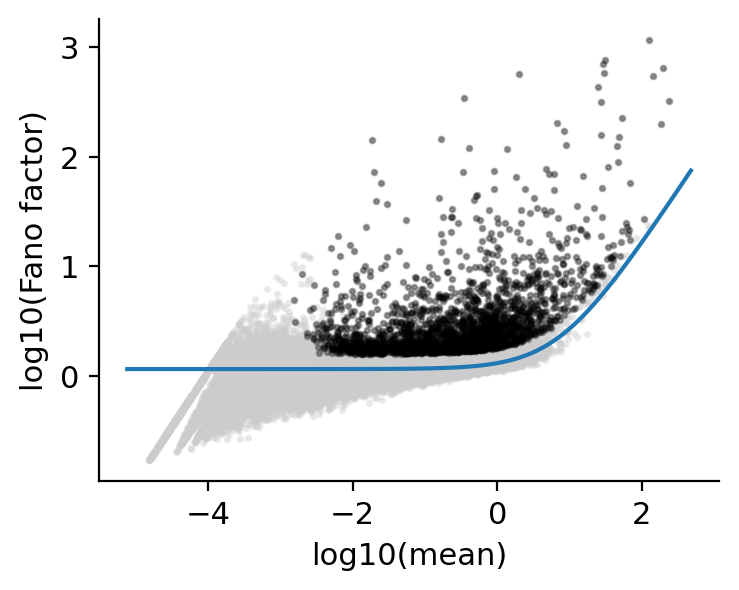

Keeping 2255 genes
Error: Provided cyclcing genes: ['Ube2c', 'Hmgb2', 'Hmgn2', 'Tuba1b', 'Ccnb1', 'Tubb5', 'Top2a', 'Tubb4b']
They are for mouse genes. Only 0 found in the reference gene list.


100%|██████████| 11064/11064 [00:00<00:00, 1531998.93it/s]

reorder clones


In [10]:
cs.pp.get_highly_variable_genes(adata_orig)
cs.pp.remove_cell_cycle_correlated_genes(adata_orig, corr_threshold=0.5, confirm_change=True)
cs.pp.get_X_clone(adata_orig, adata.obs.index.values, adata.obs.Clone_ID.values)

In [11]:
selected_fates = ["Late Erythroid", "Monocyte", "DC", "Mast cell"]

In [12]:
cs.tl.fate_coupling(adata_orig, selected_fates=selected_fates, source="X_clone") 
cs.tl.fate_hierarchy(adata_orig, selected_fates=selected_fates, source="X_clone")

normalize by X_clone
each cluster do not have a unique time point. Simply column-normalize the matrix
Results saved as dictionary at adata.uns['fate_coupling_X_clone']
normalize by X_clone
each cluster do not have a unique time point. Simply column-normalize the matrix
normalize by X_clone
each cluster do not have a unique time point. Simply column-normalize the matrix
Results saved as dictionary at adata.uns['fate_hierarchy_X_clone']


In [13]:
for fate in selected_fates:
    cs.tl.clonal_fate_bias(adata_orig, selected_fate=fate, alternative="two-sided")

  0%|          | 0/606 [00:00<?, ?it/s]

100%|██████████| 606/606 [00:00<00:00, 727.38it/s]


Data saved at adata.uns['clonal_fate_bias']


100%|██████████| 606/606 [00:00<00:00, 748.38it/s]


Data saved at adata.uns['clonal_fate_bias']


100%|██████████| 606/606 [00:00<00:00, 771.71it/s]


Data saved at adata.uns['clonal_fate_bias']


100%|██████████| 606/606 [00:00<00:00, 753.08it/s]

Data saved at adata.uns['clonal_fate_bias']


### Transition Map Inference

------Compute the full Similarity matrix if necessary------
--> Compute similarity matrix: computing new; beta=0.1
Smooth round: 1
--> Time elapsed: 0.025374889373779297
Smooth round: 2
--> Time elapsed: 0.1571500301361084
Smooth round: 3
--> Time elapsed: 0.7725486755371094
Smooth round: 4
--> Time elapsed: 1.9562182426452637
--> Orignal sparsity=0.16807915779826202, Thresholding
--> Final sparsity=0.0862753056691391
similarity matrix truncated (Smooth round=4):  1.769646406173706
Smooth round: 5
--> Time elapsed: 1.9789557456970215
--> Orignal sparsity=0.1667229274466471, Thresholding
--> Final sparsity=0.11008779720592318
similarity matrix truncated (Smooth round=5):  1.7800602912902832
--> Save the matrix at every 5 rounds
Smooth round: 6
--> Time elapsed: 2.414384365081787
--> Orignal sparsity=0.1935948715394923, Thresholding
--> Final sparsity=0.13167572916977094
similarity matrix truncated (Smooth round=6):  1.8132295608520508
Smooth round: 7
--> Time elapsed: 2.7545266151428223

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/cospar/tmap/map_reconstruction.py:237: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["data_des"] = [data_des_orig, data_des]


------Infer transition map between initial time points and the later time one------
--------Current initial time point: Day3--------
Step 1: Select time points
--> Clonal cell fraction (day Day3-Day17): 0.34557235421166305
--> Clonal cell fraction (day Day17-Day3): 0.24620132953466287
--> Numer of cells that are clonally related -- day Day3: 160  and day Day17: 2074
Number of multi-time clones post selection: 121
Cell number=8887, Clone number=121
--> clonal_cell_id_t1: 160
--> Tmap_cell_id_t1: 463
Step 2: Optimize the transition map recursively


/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/cospar/tmap/_utils.py:390: ImplicitModificationWarning: Setting element `.obsm['X_clone']` of view, initializing view as actual.
  adata.obsm["X_clone"] = clone_annot


Load pre-computed similarity matrix
--> Load from hard disk--------
--> Compute similarity matrix: load existing data
--> Time elapsed:  0.0017786026000976562
--> Time elapsed:  0.15450334548950195
--> Time elapsed:  0.004356861114501953
--> Time elapsed:  0.25446653366088867
--> Compute similarity matrix: load existing data
--> Time elapsed:  0.001619100570678711
--> Time elapsed:  0.13319635391235352
--> Time elapsed:  0.00390625
--> Time elapsed:  0.22879528999328613
--> Compute similarity matrix: load existing data
--> Time elapsed:  0.0015988349914550781
--> Time elapsed:  0.08357954025268555
--> Time elapsed:  0.0030934810638427734
--> Time elapsed:  0.2047104835510254
--> Compute similarity matrix: load existing data
--> Time elapsed:  0.0013875961303710938
--> Time elapsed:  0.07401895523071289
--> Time elapsed:  0.0017380714416503906
--> Time elapsed:  0.16501188278198242
Iteration 1, Use smooth_round=20
--> Clone normalization
--> Relative time point pair index: 0
--> Clone i

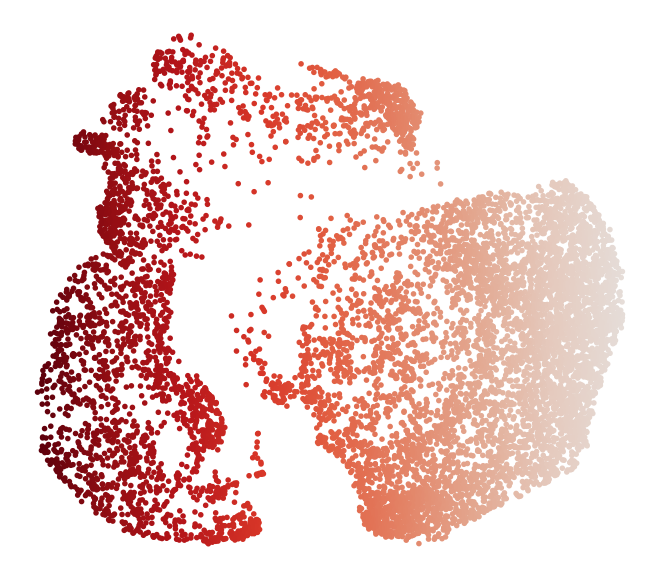

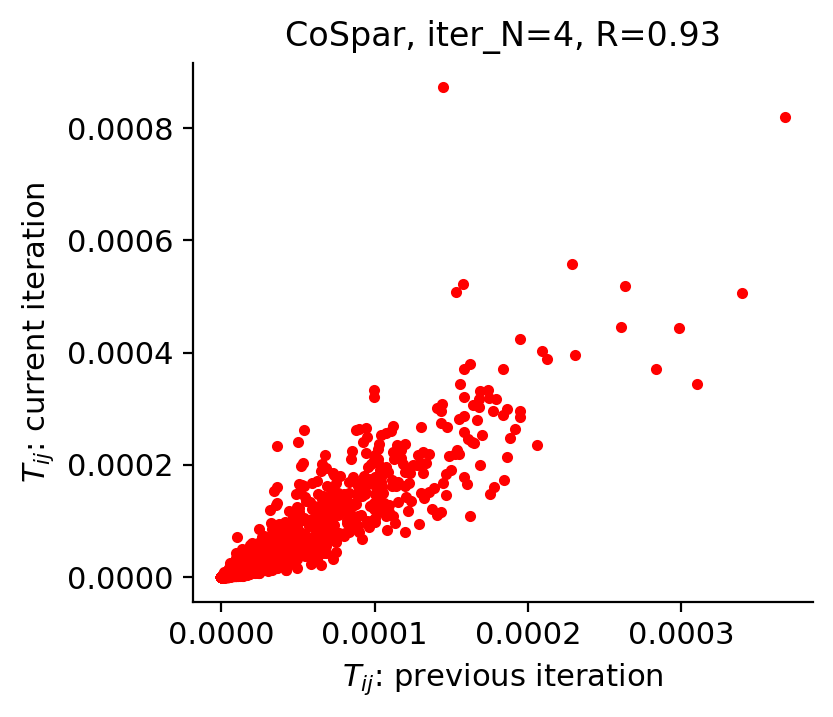

Iteration 5, Use smooth_round=5
--> Clone normalization
--> Relative time point pair index: 0
--> Clone id: 0
--> Start to smooth the refined clonal map
--> Phase I: time elapsed --  0.0180661678314209
--> Phase II: time elapsed --  0.019934415817260742


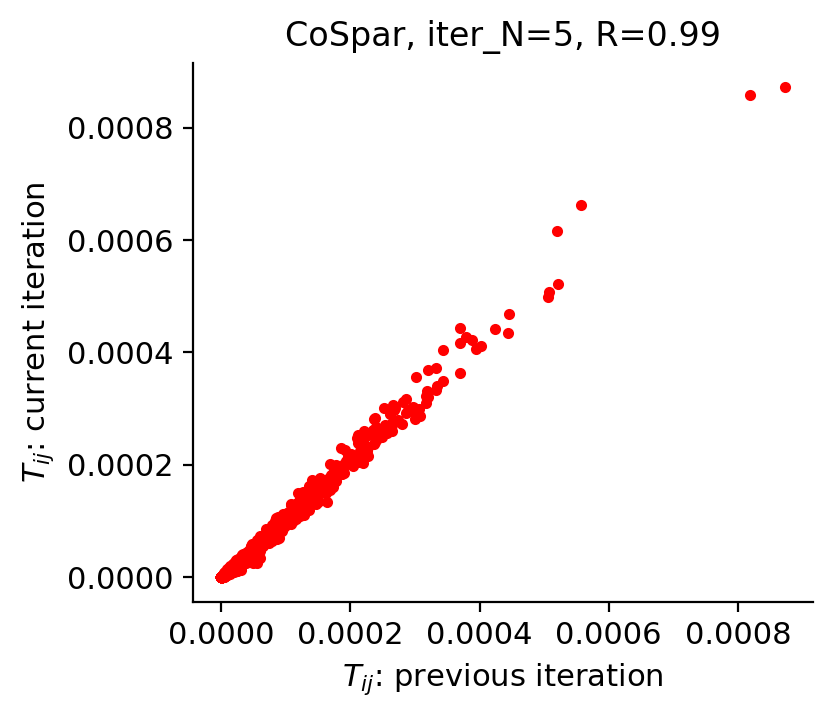

--> Final round of Smooth (to expand the state space of Tmap to include non-clonal states)
--> Phase I: time elapsed --  0.10548067092895508
--> Phase II: time elapsed --  0.11575555801391602
--> ----Intraclone transition map----
--> Clone normalization
--> Relative time point pair index: 0
--> Clone id: 0
--------Current initial time point: Day10--------
Step 1: Select time points
--> Clonal cell fraction (day Day10-Day17): 0.7473587505741847
--> Clonal cell fraction (day Day17-Day10): 0.85838081671415
--> Numer of cells that are clonally related -- day Day10: 1627  and day Day17: 7231
Number of multi-time clones post selection: 334
Cell number=10601, Clone number=334
--> clonal_cell_id_t1: 1627
--> Tmap_cell_id_t1: 2177
Step 2: Optimize the transition map recursively
Load pre-computed similarity matrix
--> Load from hard disk--------
--> Compute similarity matrix: load existing data
--> Time elapsed:  0.054924726486206055
--> Time elapsed:  0.6064014434814453
--> Time elapsed:  0.057

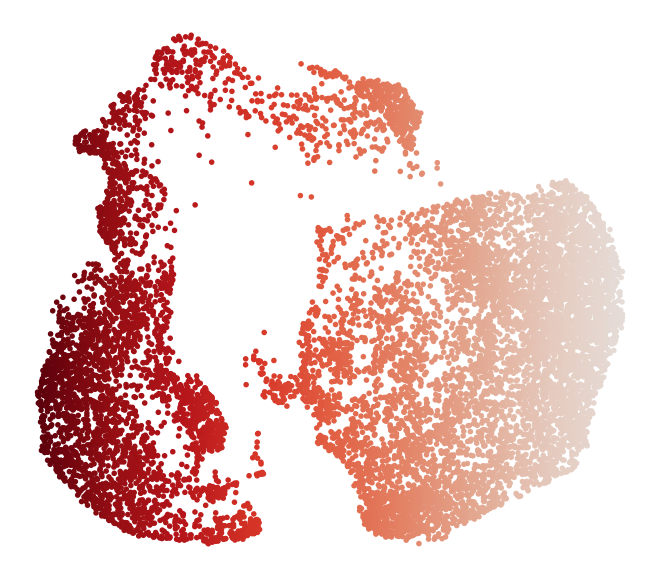

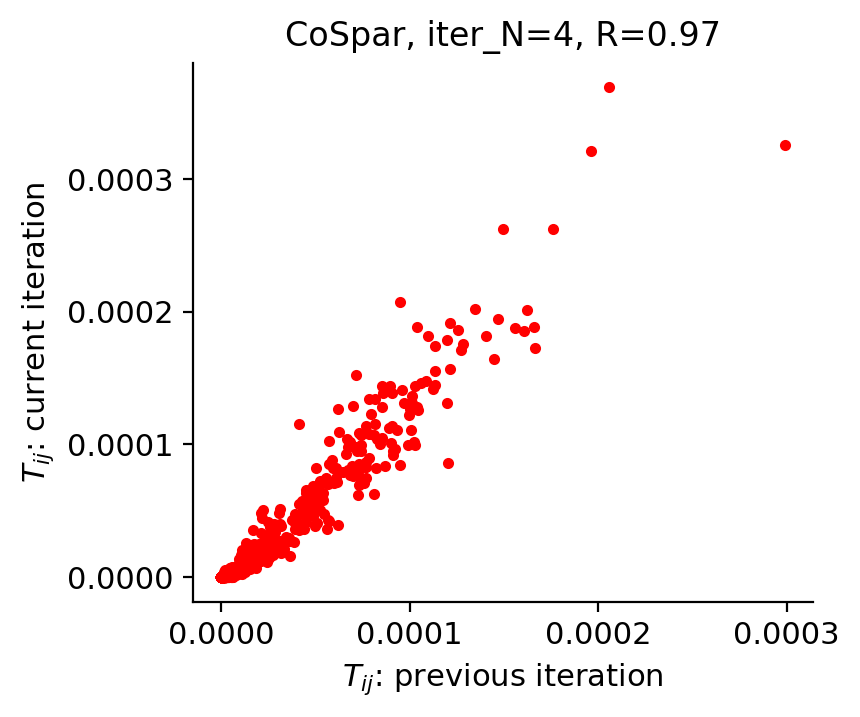

--> Final round of Smooth (to expand the state space of Tmap to include non-clonal states)
--> Phase I: time elapsed --  0.657879114151001
--> Phase II: time elapsed --  0.7357432842254639
--> ----Intraclone transition map----
--> Clone normalization
--> Relative time point pair index: 0
--> Clone id: 0
-----------Total used time: 241.41746425628662 s ------------


In [14]:
adata_all_latert = adata_orig.copy()
adata_all_latert = cs.tmap.infer_Tmap_from_multitime_clones(
    adata_all_latert,
    clonal_time_points=['Day3', 'Day10', 'Day17'],
    later_time_point='Day17',
    smooth_array=[20, 15, 10, 5],
    max_iter_N=10,
    compute_new=True
)

In [15]:
adata_all_latert

AnnData object with n_obs × n_vars = 11064 × 21924
    obs: 'time_info', 'state_info', 'n_counts'
    var: 'highly_variable'
    uns: 'data_des', 'time_ordering', 'clonal_time_points', 'clone_id', 'available_map', 'fate_coupling_X_clone', 'fate_hierarchy_X_clone', 'clonal_fate_bias', 'neighbors', 'Tmap_cell_id_t1', 'Tmap_cell_id_t2', 'clonal_cell_id_t1', 'clonal_cell_id_t2', 'sp_idx', 'transition_map', 'intraclone_transition_map'
    obsm: 'X_clone', 'X_pca', 'X_emb'
    obsp: 'distances', 'connectivities'

In [16]:
cs.tl.fate_potency(
    adata_all_latert,
    source="transition_map",
    map_backward=True,
    method="norm-sum",
    fate_count=True,
)

Results saved at adata.obs['fate_map_transition_map_MEMP']
Results saved at adata.obs['fate_map_transition_map_Mono precur']
Results saved at adata.obs['fate_map_transition_map_Monocyte']
Results saved at adata.obs['fate_map_transition_map_Mid Erythroid']
Results saved at adata.obs['fate_map_transition_map_DC']
Results saved at adata.obs['fate_map_transition_map_DC precursor']
Results saved at adata.obs['fate_map_transition_map_Late Erythroid']
Results saved at adata.obs['fate_map_transition_map_NMP']
Results saved at adata.obs['fate_map_transition_map_Early Erythroid']
Results saved at adata.obs['fate_map_transition_map_Mast cell']
Results saved at adata.obs['fate_map_transition_map_HSC/MPP 2']
Results saved at adata.obs['fate_map_transition_map_HSC/MPP 1']
Results saved at adata.obs['fate_potency_transition_map']


/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/cospar/tool/_utils.py:235: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  state_annote[cell_id_t2] == yy


### Benchmark with Gillespie

#### Init Gillespie Results

In [17]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/original/checkpoints/CordBloodDynamicRates/0603_121235/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [35]:
cluster_names = np.array(['HSC/MPP 1', 'HSC/MPP 2', 'MEMP', 'Mast cell', 'Early Erythroid',
       'Mid Erythroid', 'Late Erythroid', 'NMP', 'Mono precur',
       'Monocyte', 'DC precursor', 'DC'])

In [21]:
gillespie_dir='./trials/original//checkpoints/CordBloodDynamicGillespie/0605_131252/models/'

#### Performance Comparison

In [22]:
from clonaltrans.pl import with_cospar

In [23]:
adata_all_latert.obs['meta_clones'] = adata.obs['meta_clones'].values

/ssd/users/mingzegao/clonaltrans/clonaltrans/pl/benchmark.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('meta_clones')[f'fate_map_transition_map_{fate}'].mean()
/ssd/users/mingzegao/clonaltrans/clonaltrans/pl/benchmark.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('meta_clones')[f'fate_map_transition_map_{fate}'].mean()
/ssd/users/mingzegao/clonaltrans/clonaltrans/pl/benchmark.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt th

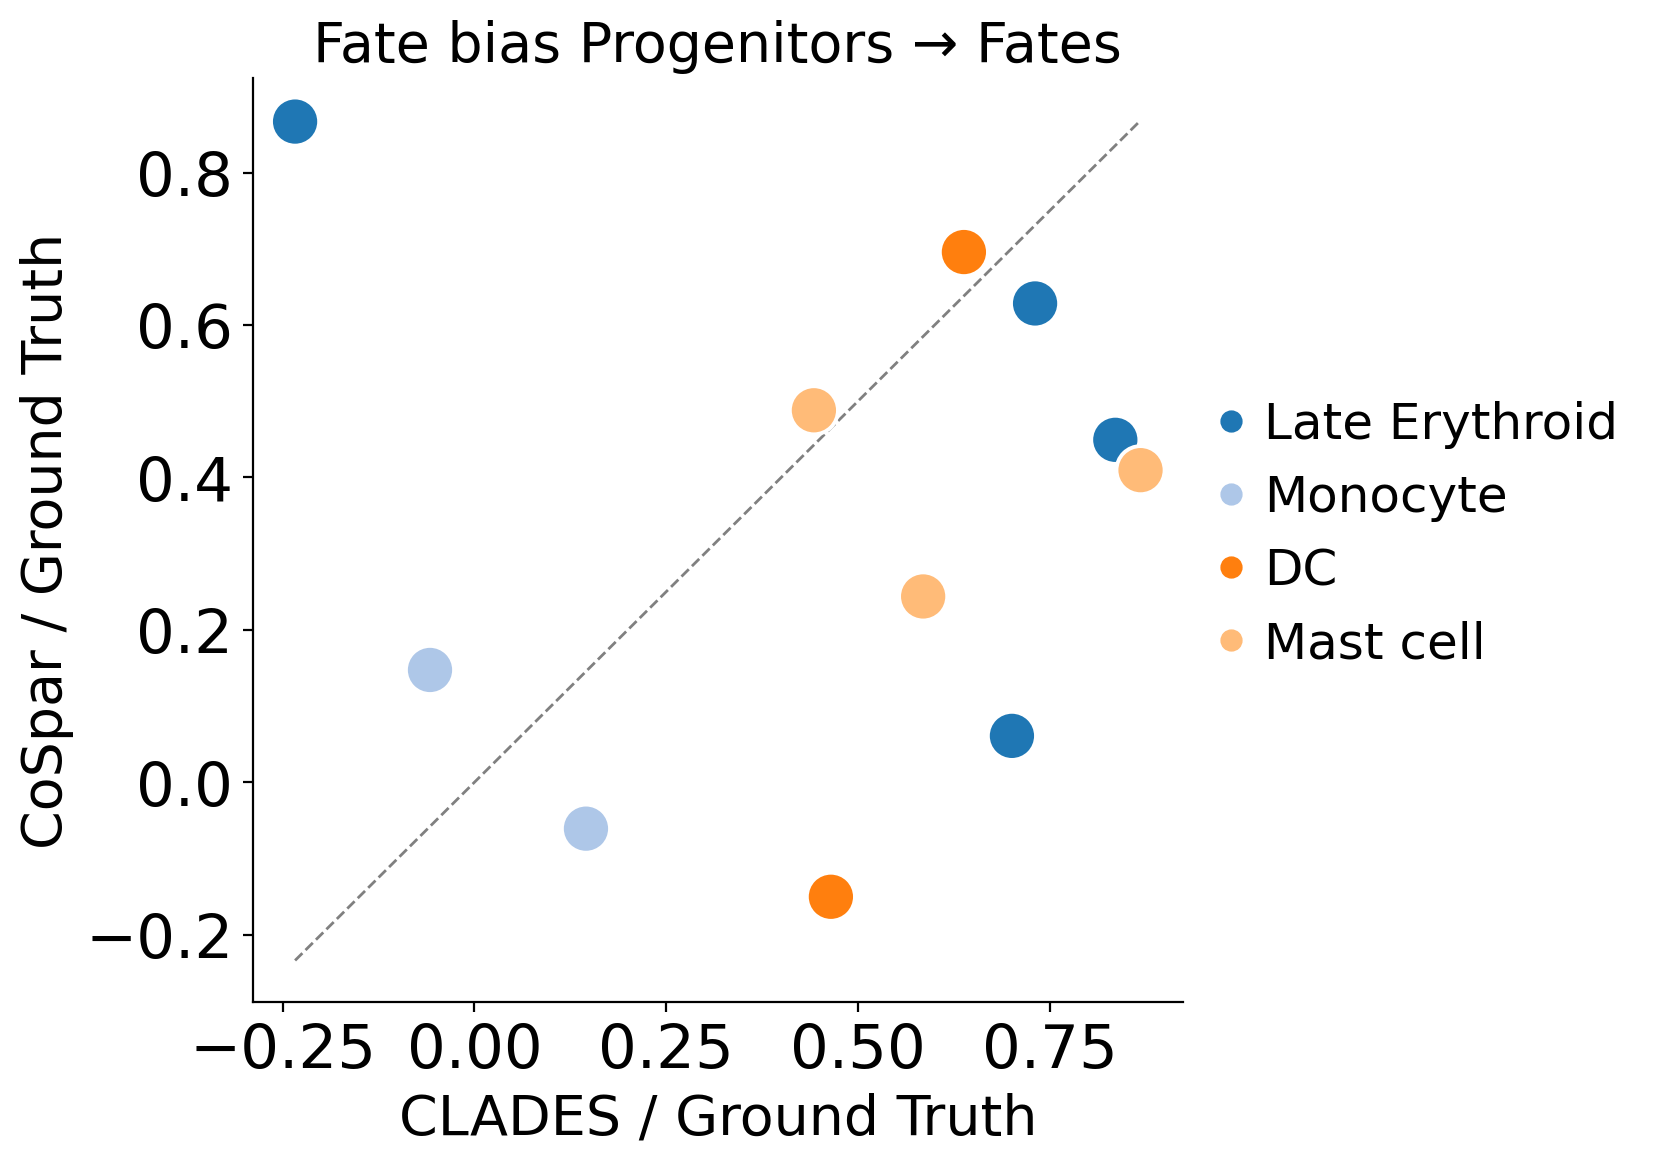

In [38]:
from clonaltrans.pl import with_cospar_all
with_cospar_all(
    adata_all_latert, 
    adata, 
    model, 
    cluster_names,
    gillespie_dir,
    selected_fates,
    selected_fates
)

/ssd/users/mingzegao/clonaltrans/clonaltrans/pl/benchmark.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('meta_clones')[f'fate_map_transition_map_{fate}'].mean()
/ssd/users/mingzegao/clonaltrans/clonaltrans/pl/benchmark.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('meta_clones')[f'fate_map_transition_map_{fate}'].mean()
/ssd/users/mingzegao/clonaltrans/clonaltrans/pl/benchmark.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt th

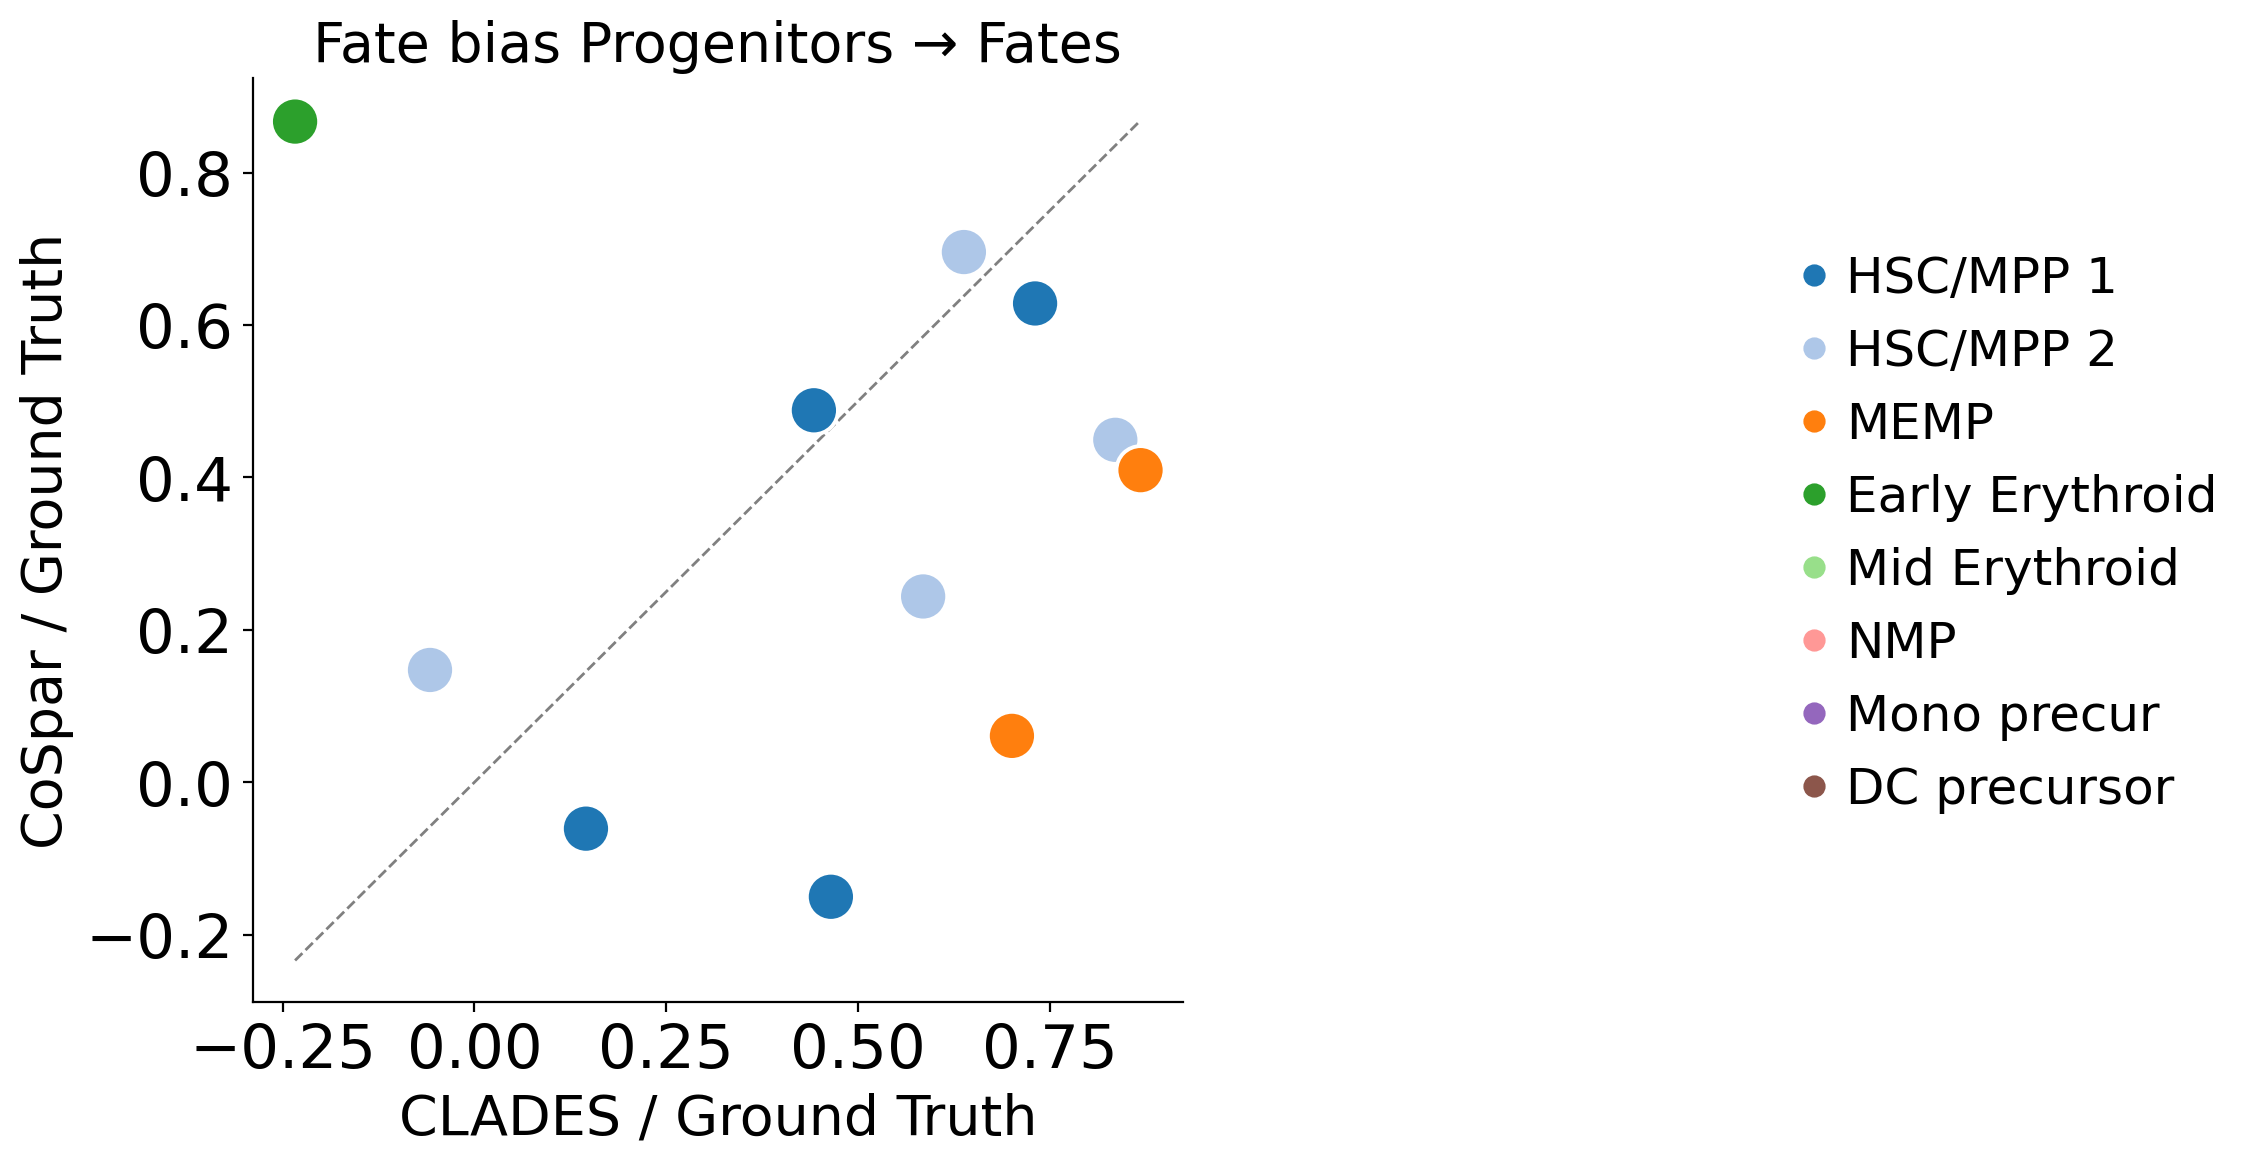

In [39]:
from clonaltrans.pl import with_cospar_all
with_cospar_all(
    adata_all_latert, 
    adata, 
    model, 
    cluster_names,
    gillespie_dir,
    selected_fates,
    selected_fates,
    show_fate=False
)

/ssd/users/mingzegao/clonaltrans/clonaltrans/pl/benchmark.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('meta_clones')[f'fate_map_transition_map_{fate}'].mean()


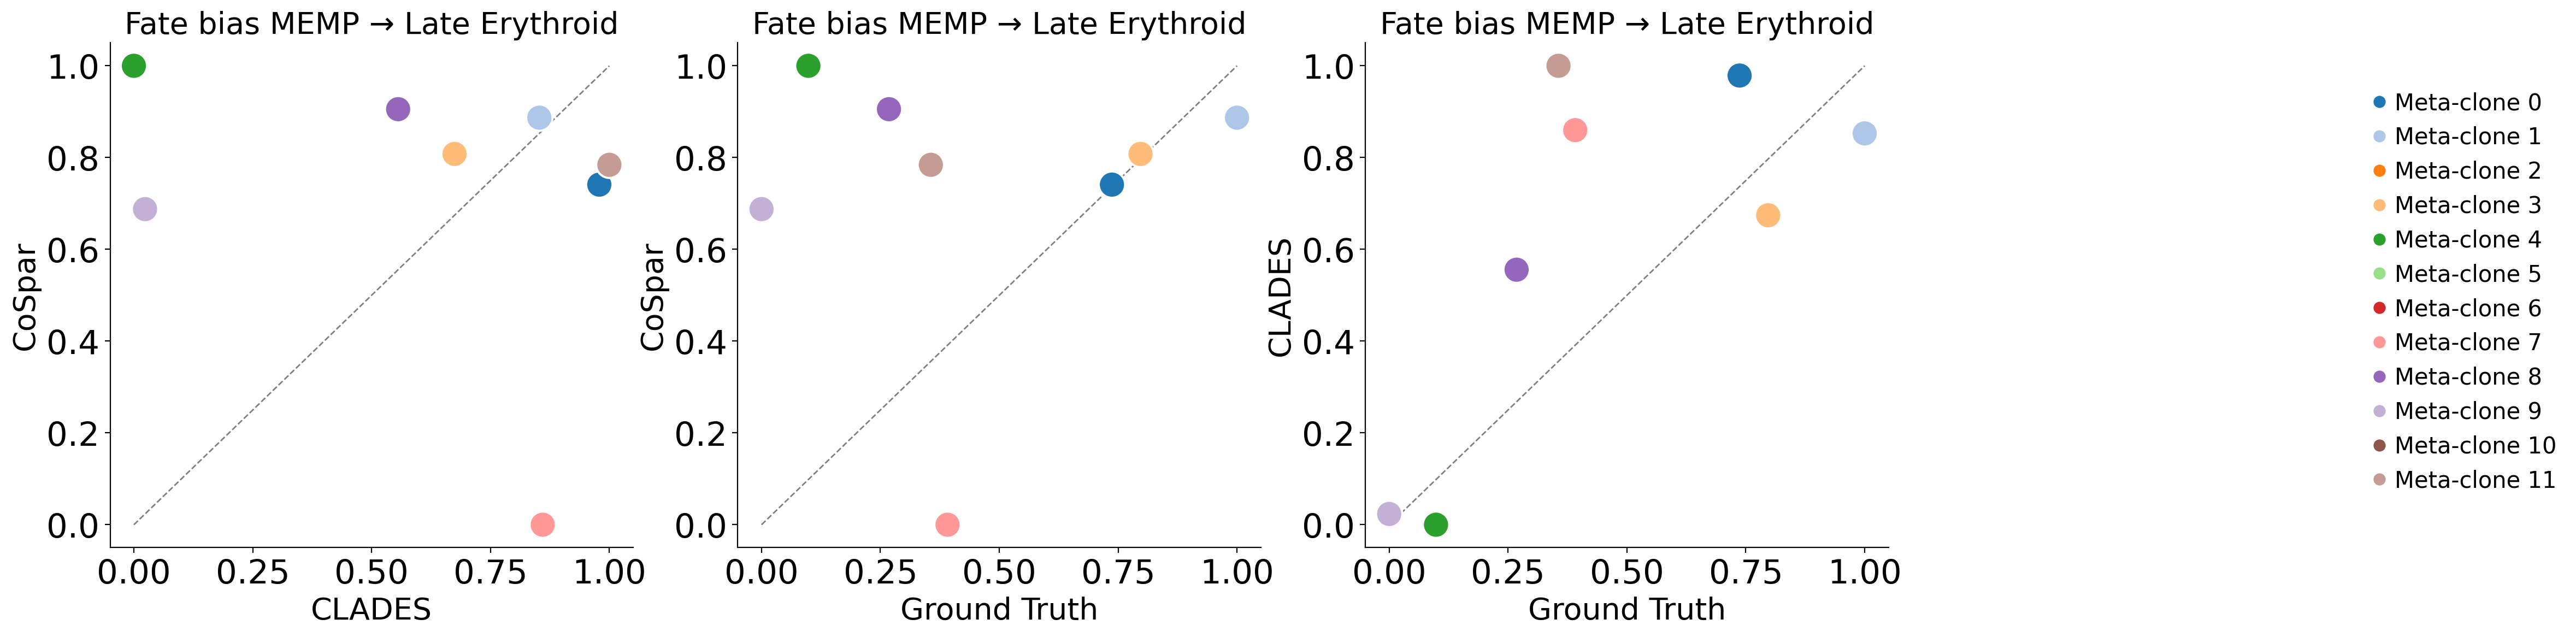

In [40]:
with_cospar(
    adata_all_latert, 
    adata, 
    'MEMP', 
    'Late Erythroid', 
    model, 
    cluster_names,
    gillespie_dir,
    selected_fates
)